# Data Format and Shape Analysis

Before analyzing the metrics, here is a brief overview of how the data is stored and shaped in the evaluation logs (`.jsonl` files):

*   **Format**: JSON Lines (JSONL). Each line is a standalone JSON object representing one sample (one turn of a dialogue).
*   **Shape/Structure**:
    ```json
    {
        "epoch": 0,
        "split": "val",       // or "test"
        "ud_idx": "123",      // Unique Dialogue ID (String)
        "ld_idx": 1,          // Local Dialogue Index (Integer, 0-based turn number)
        "metrics": {          // Nested Dictionary of Metrics
            "ppl": 10.5,
            "acc": 0.85,
            "bleu-1": 0.4,
            ...
        },
        "generated": "...",   // The model's output text
        "target": "..."       // The ground truth text
    }
    ```
*   **Aggregation Logic**: 
    *   **First Turn**: `min(ld_idx)` for a given `ud_idx`.
    *   **Last Turn**: `max(ld_idx)` for a given `ud_idx`.

# Generation Task Metric Analysis
This notebook analyzes the evaluation results from the Generation Task. 
It focuses on comparing the performance of the model on the **First Turn** vs **Last Turn** of each dialogue.

## Requirements
1.  Compute average metrics of **FIRST-TURN** and **LAST-TURN** for each dialogue.
2.  Count how many dialogues have **FIRST-TURN** results better than **LAST-TURN** results.


In [77]:
import os
import glob, re
import json, nltk
import pandas as pd
import numpy as np
from typing import Dict, List, Optional

# 1. Setup Path
# We search for 'eval_results*.jsonl' in the outputs directory
# Adjust this base path if needed
BASE_OUTPUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs'))

# Target Folders as requested
TARGET_FOLDERS = [
    # 'Qwen3_02-15',
    # 'Qwen3Gen_03-26',
    # 'raw_model_Gen_llama3.1_2-24',
    # 'raw_model_Gen_Qwen3_2-24',
    # 'raw_model_Gen_llama3.1_2-25',
    # 'raw_model_Gen_Qwen3_2-25',
    # 'raw_model_Gen_Qwen3_2-26',
    # "Qwen3Gen_03-05",
    # "llama3.1Gen_02-24",
    # "llama3.1Gen_03-08",
    # "llama3.1Gen_03-26",
    # "llama3.1Gen_03-30",
    "llama3.1Gen_03-31",
    # '../'
    # 'raw_model_Gen_Qwen3_3-4',
    
    # 'eval_results',
]

outer_files = [
    "../"
]

jsonl_files = []

print(f"Searching in: {BASE_OUTPUT_DIR}")
for folder in TARGET_FOLDERS:
    # Construct search path: outputs/{folder_name}/**/eval_logs/*.jsonl
    search_path = os.path.join(BASE_OUTPUT_DIR, folder, '**', 'eval_logs', '*.jsonl')
    found_files = glob.glob(search_path, recursive=True)
    
    # Fallback search if 'eval_logs' not found directly inside (e.g. might be simpler structure)
    if not found_files:
         search_path = os.path.join(BASE_OUTPUT_DIR, folder, '**', '*.jsonl')
         found_files = glob.glob(search_path, recursive=True)
         
    jsonl_files.extend(found_files)

outside_files = list()
for outsider in outer_files:
    search_p = os.path.join(BASE_OUTPUT_DIR, outsider, '*.jsonl')
    found_files = glob.glob(search_p, recursive=False)

    outside_files.extend(found_files)

print(f"[Total] Found {len(jsonl_files)} log files.")
for f in jsonl_files:
    print(f"[Total] - {f}")
    
repattern, repattern2 = r"\w+_last_(test|val)", r"eval_results?_\w+_test"
jsonl_files = [jf for jf in jsonl_files if re.search(repattern, jf, flags=re.IGNORECASE) or re.search(repattern2, jf, flags=re.IGNORECASE)]

# jsonl_files.extend(outside_files)
print(f"[After] Found {len(jsonl_files)} log files.")
for f in jsonl_files:
    print(f" - {f}")

Searching in: /home/new/Documents/QSH/Llama_train/outputs
[Total] Found 6 log files.
[Total] - /home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio01turn1/eval_logs/eval_results_epoch_test_0_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio01turn1/eval_logs/eval_results_epoch_val_0_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio005turn1_iamm_sit_learning/eval_logs/eval_results_epoch_test_0_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio005turn1_iamm_sit_learning/eval_logs/eval_results_epoch_val_0_rank_0.jsonl
[Total] - /home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio003turn1_ia

In [78]:
from collections import Counter
import numpy as np

# --- 1. The Baidu NLP Function ---
def distinct(seqs):
    """ Calculate intra/inter distinct 1/2. """
    batch_size = len(seqs)
    intra_dist1, intra_dist2 = [], []
    unigrams_all, bigrams_all = Counter(), Counter()
    
    for seq in seqs:
        # Intra: Diversity within a single sentence
        unigrams = Counter(seq)
        bigrams = Counter(zip(seq, seq[1:]))
        intra_dist1.append((len(unigrams)+1e-12) / (len(seq)+1e-5))
        intra_dist2.append((len(bigrams)+1e-12) / (max(0, len(seq)-1)+1e-5))

        # Update global counts for Inter metrics
        unigrams_all.update(unigrams)
        bigrams_all.update(bigrams)

    # Inter: Diversity across the whole set of sentences (the whole dialogue)
    inter_dist1 = (len(unigrams_all)+1e-12) / (sum(unigrams_all.values())+1e-5)
    inter_dist2 = (len(bigrams_all)+1e-12) / (sum(bigrams_all.values())+1e-5)
    intra_dist1 = np.average(intra_dist1)
    intra_dist2 = np.average(intra_dist2)
    return intra_dist1, intra_dist2, inter_dist1, inter_dist2

In [79]:
# 2. Load Data into DataFrame
data_records = []
from metrics_func import calculate_bleu

for file_path in jsonl_files:
    # Attempt to extract experiment/run name from path
    # Path format: .../outputs/{Experiment}/{Run}/eval_logs/...
    rel_path = os.path.relpath(file_path, BASE_OUTPUT_DIR)
    parts = rel_path.split(os.sep)
    
    # Heuristic for experiment name
    exp_name = "check_logs" # Default
    if len(parts) >= 2 and len(parts)<4:
        exp_name = f"{parts[0]}/{parts[1]}"
    elif len(parts) >=4:
        pattern = r"^method_SSP_bs_[0-9]_inputdata_input_text_(.+)$"
        match, captured = re.match(pattern, parts[1]), 'na'
        if match:
            captured = match.group(1)
        exp_name = f"{captured}/{parts[-1]}"
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                record = json.loads(line)
                
                # Flatten metrics for easier pandas use
                metrics = record.pop('metrics', {})
                for k, v in metrics.items():
                    record[f'metric_{k}'] = v
                
                # Add metadata
                record['source_file'] = file_path
                record['experiment'] = exp_name
                
                if 'epoch' not in record:
                    record['epoch'] = -1
                
                # Ensure types
                record['ud_idx'] = str(record.get('ud_idx', 'unknown'))
                record['ld_idx'] = int(record.get('ld_idx', -1))
                
                gen_words = record.get('generated', '')
                ref_words = record.get('target', record.get('reference', ''))
                b1, b2 = calculate_bleu(gen_words, ref_words)
                record['metric_bleu-1'] = b1
                record['metric_bleu-2'] = b2
                
                data_records.append(record)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

df = pd.DataFrame(data_records)
print(f"Loaded {len(df)} records.")
if not df.empty:
    display(df.head())
else:
    print("No data found. Please ensure 'eval_logs' exist and contain valid jsonl files.")


Loaded 15765 records.


,epoch,split,generated,target,metric_ppl,metric_acc,metric_bleu-1,metric_bleu-2,metric_dist-1,metric_dist-2,source_file,experiment,ud_idx,ld_idx
0,0,test,that is crazy. i am glad you were not injured.,why did you feel guilty ? people really should...,7.772397,0.534483,0.153846,0.035806,0.039254,0.209477,/home/new/Documents/QSH/Llama_train/outputs/ll...,task3_Llama31_ratio01turn1/eval_results_epoch_...,unknown,-1
1,0,test,"yes, i am okay now and the drunk driver did go...",yeah he was punished hes in jail still,11.836049,0.534483,0.059046,0.019961,0.039254,0.209477,/home/new/Documents/QSH/Llama_train/outputs/ll...,task3_Llama31_ratio01turn1/eval_results_epoch_...,unknown,-1
2,0,test,"wow, that is crazy. did you get any compensation?",did you suffer any injuries ?,5.246920,0.534483,0.245253,0.134331,0.039254,0.209477,/home/new/Documents/QSH/Llama_train/outputs/ll...,task3_Llama31_ratio01turn1/eval_results_epoch_...,unknown,-1
3,0,test,i am not sure. i think you have more experience.,yeah i wanted to tell you about the time i was...,13.115382,0.534483,0.153846,0.024807,0.039254,0.209477,/home/new/Documents/QSH/Llama_train/outputs/ll...,task3_Llama31_ratio01turn1/eval_results_epoch_...,unknown,-1
4,0,test,i know how you feel. it is hard to break up wi...,sorry again ! hope you will get relief from th...,18.326975,0.484848,0.158084,0.065926,0.039254,0.209477,/home/new/Documents/QSH/Llama_train/outputs/ll...,task3_Llama31_ratio01turn1/eval_results_epoch_...,unknown,-1


In [80]:
jsonl_files

['/home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio01turn1/eval_logs/eval_results_epoch_test_0_rank_0.jsonl',
 '/home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio005turn1_iamm_sit_learning/eval_logs/eval_results_epoch_test_0_rank_0.jsonl',
 '/home/new/Documents/QSH/Llama_train/outputs/llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio003turn1_iamm_sit_learning/eval_logs/eval_results_epoch_test_0_rank_0.jsonl']

### Specificlly designed for all/avg PPL computation

In [81]:
# 2. Load Data into DataFrame
grouped_data = dict()
from metrics_func import calculate_bleu
for file_path in jsonl_files:
    # Attempt to extract experiment/run name from path
    # Path format: .../outputs/{Experiment}/{Run}/eval_logs/...
    rel_path = os.path.relpath(file_path, BASE_OUTPUT_DIR)
    parts = rel_path.split(os.sep)
    inside_staits_records = list()
    
    print('rel_path:', rel_path, 'parts:', parts)
    
    # Heuristic for experiment name
    exp_name = "check_logs" # Default
    if len(parts) >= 2 and len(parts)<4:
        part_name1 = '_'.join(parts[1].split('_')[-2:])
        exp_name = f"{parts[0]}/{parts[1]}"
        key_name = f"{part_name1}/{parts[-1].split('.')[0]}"
    elif len(parts) >=4:
        pattern = r"^method_SSP_bs_[0-9]_inputdata_input_text_(.+)$"
        match, captured = re.match(pattern, parts[1]), 'na'
        if match:
            captured = match.group(1)
        exp_name = f"{captured}/{parts[-1]}"
        key_name = f"{captured}/{parts[-1].split('.')[0]}"
        
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip(): continue
                record = json.loads(line)
                
                # Add metadata
                record['source_file'] = file_path
                record['experiment'] = exp_name
                
                if 'epoch' not in record:
                    record['epoch'] = -1
                
                # Ensure types
                record['ud_idx'] = str(record.get('ud_idx', 'unknown'))
                record['ld_idx'] = int(record.get('ld_idx', -1))
                
                gen_words = record.get('generated', '')
                ref_words = record.get('target', record.get('reference', ''))
                b1, b2 = calculate_bleu(gen_words, ref_words)
                
                if 'metrics' not in record:
                    record['metrics'] = {}
                record['metrics']['bleu-1'] = b1
                record['metrics']['bleu-2'] = b2
                
                inside_staits_records.append(record)
            grouped_data[key_name] = inside_staits_records
            print(f'\n\nkey name: {key_name}')
    except Exception as e:
        print(f"Error reading {file_path}: {e}")


rel_path: llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio01turn1/eval_logs/eval_results_epoch_test_0_rank_0.jsonl parts: ['llama3.1Gen_03-31', 'method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio01turn1', 'eval_logs', 'eval_results_epoch_test_0_rank_0.jsonl']


key name: task3_Llama31_ratio01turn1/eval_results_epoch_test_0_rank_0
rel_path: llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio005turn1_iamm_sit_learning/eval_logs/eval_results_epoch_test_0_rank_0.jsonl parts: ['llama3.1Gen_03-31', 'method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio005turn1_iamm_sit_learning', 'eval_logs', 'eval_results_epoch_test_0_rank_0.jsonl']


key name: task3_Llama31_ratio005turn1_iamm_sit_learning/eval_results_epoch_test_0_rank_0
rel_path: llama3.1Gen_03-31/method_SSP_bs_4_inputdata_input_text_task3_Llama31_ratio003turn1_iamm_sit_learning/eval_logs/eval_results_epoch_test_0_rank_0.jsonl parts: ['llama3.1Gen_03-31', 'method_SSP_bs_4_inputdata

In [82]:
for key in grouped_data:
    print(f"Experiment: {key}, Number of Records: {len(grouped_data[key])}")

Experiment: task3_Llama31_ratio01turn1/eval_results_epoch_test_0_rank_0, Number of Records: 5255
Experiment: task3_Llama31_ratio005turn1_iamm_sit_learning/eval_results_epoch_test_0_rank_0, Number of Records: 5255
Experiment: task3_Llama31_ratio003turn1_iamm_sit_learning/eval_results_epoch_test_0_rank_0, Number of Records: 5255


In [83]:
top_k_dict = {
    'Llama3.1_FSL16/eval_results_FSL_4shots_last_test': 0,
    'Llama3.1_FSL16/eval_results_FSL_16shots_last_test': 0,
    'Llama3.1_SSL02/eval_results_FSL_4shots_last_test': 0,
    'Llama31_SSL01/eval_results_FSL_4shots_last_test': 0,
    'Llama3.1_SSL02/eval_results_epoch_test_2_rank_0': 0,
    'Llama3.1_SSL02/eval_results_epoch_val_2_rank_0': 0,
}

for modelres in grouped_data:
    record_metrics = dict()
    ppl_list = list()
    inside_list = list()
    top_k = 0
    
    for idx, singleres in enumerate(grouped_data[modelres]):
        target_text = singleres.get('reference', '')
        if target_text == '':
            target_text = singleres.get('target', '')
        metrics = singleres.get('metrics', {})
        if not len(metrics) or len(target_text)<2: 
            top_k+=1
        
        for key, value in metrics.items():
            if value == np.inf or value == -np.inf or np.isnan(value):
                continue
            if key == 'ppl':
                ppl_list.append(value)
            if key not in record_metrics:
                record_metrics[key] = (value, 1)
            else:
                current_sum, current_count = record_metrics[key]
                record_metrics[key] = (current_sum + value, current_count + 1)
    ppl_list = sorted(ppl_list, reverse=True)
    ppl_adjusted_list = ppl_list[top_k:]
    # print(f"Deleted PPL values are {ppl_list[:top_k_dict[modelres]]}")
    record_metrics['adjust_ppl'] = (sum(ppl_adjusted_list), len(ppl_adjusted_list))
    
    print(f"Model: {modelres}")
    for key, (total, count) in record_metrics.items():
        avg_value = total / count if count > 0 else 0
        print(f"  {key}: {avg_value:.4f} (based on {count} samples)")
    
    print('\n\n')

Model: task3_Llama31_ratio01turn1/eval_results_epoch_test_0_rank_0
  ppl: 43.1163 (based on 5255 samples)
  acc: 0.4929 (based on 5255 samples)
  bleu-1: 0.1708 (based on 5255 samples)
  bleu-2: 0.0747 (based on 5255 samples)
  dist-1: 0.0393 (based on 5255 samples)
  dist-2: 0.2095 (based on 5255 samples)
  adjust_ppl: 11.4613 (based on 5252 samples)



Model: task3_Llama31_ratio005turn1_iamm_sit_learning/eval_results_epoch_test_0_rank_0
  ppl: 54.5741 (based on 5255 samples)
  acc: 0.4813 (based on 5255 samples)
  bleu-1: 0.1637 (based on 5255 samples)
  bleu-2: 0.0703 (based on 5255 samples)
  dist-1: 0.0464 (based on 5255 samples)
  dist-2: 0.2471 (based on 5255 samples)
  adjust_ppl: 13.9090 (based on 5252 samples)



Model: task3_Llama31_ratio003turn1_iamm_sit_learning/eval_results_epoch_test_0_rank_0
  ppl: 30.8988 (based on 5255 samples)
  acc: 0.4811 (based on 5255 samples)
  bleu-1: 0.1639 (based on 5255 samples)
  bleu-2: 0.0714 (based on 5255 samples)
  dist-1: 0.0378 (base

In [25]:
length = len(data_records)

ppl_list = [data_records[i].get('metric_ppl') for i in range(length)]
print(f"{sum(ppl_list)/length:.2f}")

38.76


In [26]:
# 3. Analyze First vs Last Turn
# We need to perform the analysis for each unique experiment and epoch separately.

def analyze_group(group_df):
    """
    Computes analysis for a single group (e.g. one epoch of one experiment).
    Returns nested dictionary with results.
    """
    # 1. Identify First and Last Turns per Unique Dialogue
    # Sort by ud_idx and ld_idx just to be safe
    overall_ppl = group_df['metric_ppl'].mean()
    group_df = group_df.sort_values(['ud_idx', 'ld_idx'])
    
    # Group by Unique Dialogue ID
    dialogue_groups = group_df.groupby('ud_idx')
    
    # Extract First and Last turns
    first_turn_df = dialogue_groups.first().reset_index()
    last_turn_df = dialogue_groups.last().reset_index()
    
    # Limit columns to metrics
    metric_cols = [c for c in group_df.columns if c.startswith('metric_')]
    # assert avg_first.shape[0] == avg_last.shape[0], ''
    
    # 2. Compute Averages
    avg_first = first_turn_df.loc[:, metric_cols].mean().to_dict()
    avg_last = last_turn_df.loc[:, metric_cols].mean().to_dict()
    
    # 3. Compare First vs Last Turn Performance (Count "Better")
    # Join on ud_idx to compare same dialogue
    comparison_df = pd.merge(
        first_turn_df[['ud_idx'] + metric_cols],
        last_turn_df[['ud_idx'] + metric_cols],
        on='ud_idx',
        suffixes=('_first', '_last')
    )
    
    # Filter out dialogues with only 1 turn? (First == Last)
    # The requirement asks "collect in all unique dialogue...". Usually this implies valid transitions.
    # If a dialogue has only 1 turn, it cannot "improve" or "degrade". 
    # But technically First is Better than Last is False if they are equal.
    # We will stick to strict inequality.
    
    comparison_stats = {}
    total_dialogues = len(comparison_df)
    
    for metric in metric_cols:
        col_first = f"{metric}_first"
        col_last = f"{metric}_last"
        
        # Determine direction of "Better"
        if 'ppl' in metric.lower() or 'loss' in metric.lower():
            # Lower is Better
            # First Better means First < Last
            is_better = comparison_df[col_first] < comparison_df[col_last]
        else:
            # Higher is Better (BLEU, Acc, Dist)
            # First Better means First > Last
            is_better = comparison_df[col_first] > comparison_df[col_last]
            
        count = is_better.sum()
        
        comparison_stats[metric] = {
            "first_better_count": int(count),
            "total_dialogues": int(total_dialogues),
            "ratio": round(count / total_dialogues, 4) if total_dialogues > 0 else 0
        }
        
    return {
        "metrics_average": {
            'overall_ppl': overall_ppl,
            "first_turn": avg_first,
            "last_turn": avg_last
        },
        "comparison_first_better_than_last": comparison_stats
    }

# Run Analysis
final_results = {}

if not df.empty:
    # Group by key experimental factors
    # experiment: inferred from path
    # epoch, split: from file content
    group_keys = ['experiment', 'epoch', 'split']
    grouped = df.groupby(group_keys)
    
    for name, group in grouped:
        # name is tuple (exp, epoch, split)
        key_str = f"{name[0]} | Epoch {name[1]} | {name[2]}"
        print(f"Analyzing Group: {key_str} (Records: {len(group)})")
        
        res = analyze_group(group)
        final_results[key_str] = res
else:
    print("No data to analyze.")

# Output
print("\n" + "="*40)
print("Analysis Complete. Results:")
print("="*40)
print(json.dumps(final_results, indent=4))


Analyzing Group: task3_ratio02turn1_Llama31_iamm_sit_learning/eval_results_epoch_test_0_rank_0.jsonl | Epoch 0 | test (Records: 5255)

Analysis Complete. Results:
{
    "task3_ratio02turn1_Llama31_iamm_sit_learning/eval_results_epoch_test_0_rank_0.jsonl | Epoch 0 | test": {
        "metrics_average": {
            "overall_ppl": 38.75713709067663,
            "first_turn": {
                "metric_ppl": 8.707032203674316,
                "metric_acc": 0.568965494632721,
                "metric_bleu-1": 0.14285714285714285,
                "metric_bleu-2": 5.637975647982813e-155,
                "metric_dist-1": 0.038760835303388495,
                "metric_dist-2": 0.20270558683981546
            },
            "last_turn": {
                "metric_ppl": 2.6768674850463867,
                "metric_acc": 0.53125,
                "metric_bleu-1": 0.0,
                "metric_bleu-2": 0.0,
                "metric_dist-1": 0.038760835303388495,
                "metric_dist-2": 0.20270558

Plotting for: llama3.1Gen_02-24/method_FSL_bs_2_inputdata_input_text_Llama3.1_FSL16 | Epoch -1 | last_test


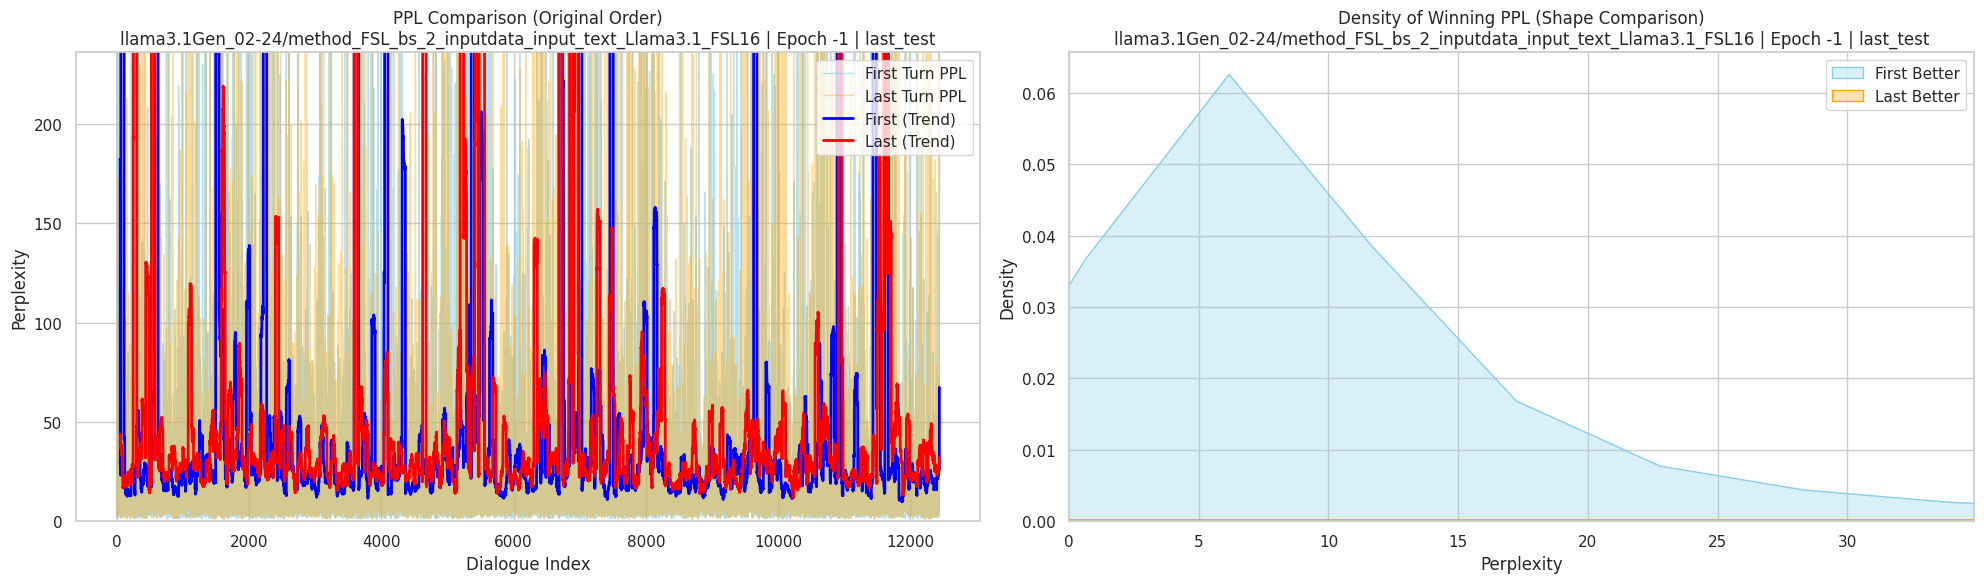

Plotting for: llama3.1Gen_03-06/method_SSP_bs_2_inputdata_input_text_Llama3.1_SSL02 | Epoch -1 | last_test


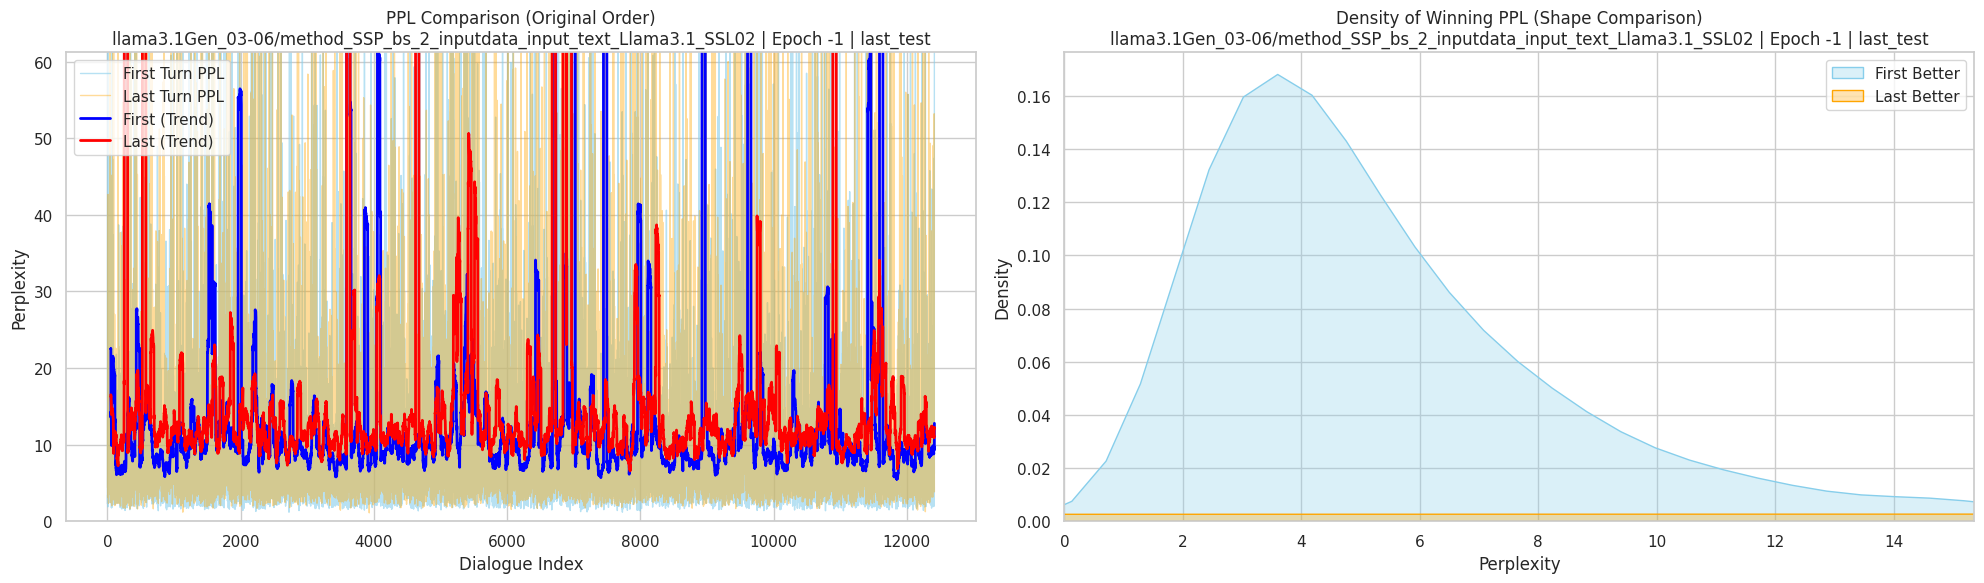

Plotting for: llama3.1Gen_03-08/method_SSP_bs_2_inputdata_input_text_Llama31_SSL01 | Epoch -1 | last_test


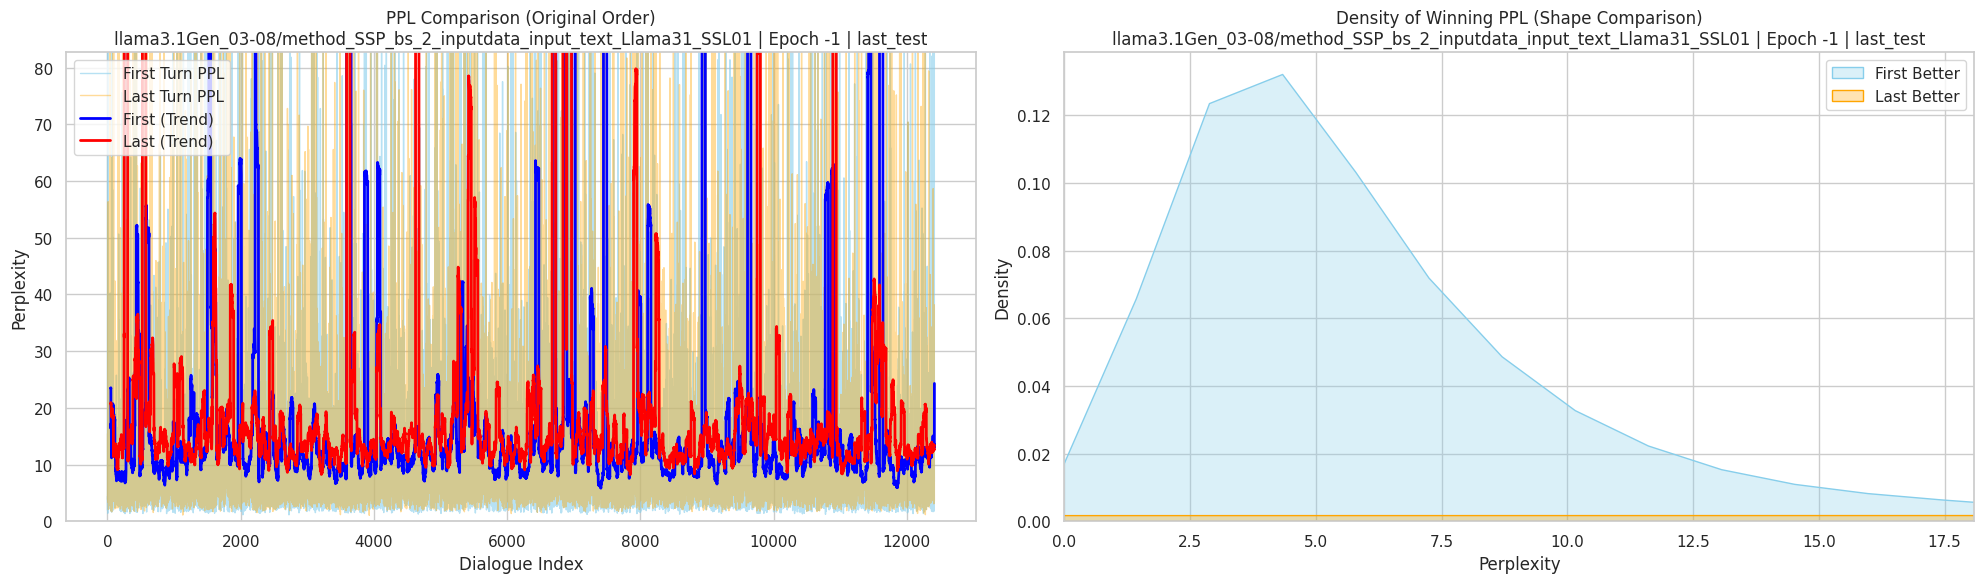

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visuals
sns.set_theme(style="whitegrid")

def plot_ppl_distribution(group_df, title_suffix=""):
    """
    Plots the distribution of PPL for dialogues where First Turn is Better vs Last Turn is Better.
    """
    # 1. Prepare Data
    group_df = group_df.sort_values(['ud_idx', 'ld_idx'])
    dialogue_groups = group_df.groupby('ud_idx')
    
    first_turn_df = dialogue_groups.first().reset_index()
    last_turn_df = dialogue_groups.last().reset_index()
    
    # Merge for comparison
    metric = 'metric_ppl' 
    if metric not in first_turn_df.columns:
        print(f"Metric {metric} not found.")
        return

    # Ensure alignment by merging (so we only compare valid pairs)
    comparison_df = pd.merge(
        first_turn_df[['ud_idx', metric]],
        last_turn_df[['ud_idx', metric]],
        on='ud_idx',
        suffixes=('_first', '_last')
    ).reset_index(drop=True)  # preserve original load order, no sort
    
    # 2. Categorize for Right Plot
    first_better_mask = comparison_df[f'{metric}_first'] < comparison_df[f'{metric}_last']
    data_first_better = comparison_df[first_better_mask][f'{metric}_first']
    data_last_better = comparison_df[~first_better_mask][f'{metric}_last']
    
    # 3. Plot
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    # --- LEFT PLOT: Original distribution order (no sorting) ---
    axes[0].plot(comparison_df.index, comparison_df[f'{metric}_first'], color="skyblue", label="First Turn PPL", alpha=0.6, linewidth=1)
    axes[0].plot(comparison_df.index, comparison_df[f'{metric}_last'], color="orange", label="Last Turn PPL", alpha=0.4, linewidth=1)
    
    # Moving average trend lines
    axes[0].plot(comparison_df[f'{metric}_first'].rolling(window=50).mean(), color="blue", label="First (Trend)", linewidth=2)
    axes[0].plot(comparison_df[f'{metric}_last'].rolling(window=50).mean(), color="red", label="Last (Trend)", linewidth=2)

    axes[0].set_title(f"PPL Comparison (Original Order)\n{title_suffix}")
    axes[0].set_xlabel("Dialogue Index")
    axes[0].set_ylabel("Perplexity")
    axes[0].legend()
    
    # Limit Y to ignore extreme spikes
    y_limit = comparison_df[[f'{metric}_first', f'{metric}_last']].quantile(0.98).max()
    axes[0].set_ylim(0, y_limit)


    # --- RIGHT PLOT: Density Estimation of Winning Scores ---
    sns.kdeplot(data_first_better, color="skyblue", label="First Better", fill=True, alpha=0.3, ax=axes[1])
    sns.kdeplot(data_last_better, color="orange", label="Last Better", fill=True, alpha=0.3, ax=axes[1])
    
    axes[1].set_title(f"Density of Winning PPL (Shape Comparison)\n{title_suffix}")
    axes[1].set_xlabel("Perplexity")
    axes[1].set_ylabel("Density")
    
    all_vals = pd.concat([data_first_better, data_last_better])
    if not all_vals.empty:
        axes[1].set_xlim(0, all_vals.quantile(0.95))
        
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Run Plotting Loop
if not df.empty:
    group_keys = ['experiment', 'epoch', 'split']
    grouped = df.groupby(group_keys)
    
    for name, group in grouped:
        key_str = f"{name[0]} | Epoch {name[1]} | {name[2]}"
        print(f"Plotting for: {key_str}")
        plot_ppl_distribution(group, title_suffix=key_str)
else:
    print("No data to plot.")


## Conclusion on Data Storage and Formatting

Based on the analysis code above:
1.  **Storage Format**: The evaluation results are stored in JSON Lines (`.jsonl`) format. Each line represents the evaluation result for a single turn of a dialogue.
2.  **Key Identifiers**:
    *   `ud_idx`: Unique Dialogue ID, used to group turns belonging to the same conversation.
    *   `ld_idx`: Local/Internal Dialogue Index, used to order the turns within a dialogue (min = First Turn, max = Last Turn).
3.  **Metrics**: Standard metrics (Perplexity, BLEU, etc.) are nested under the `metrics` key in each JSON object.
4.  **File Organization**: Files are separated by `epoch`, `split` (val/test), and `rank` (for multi-GPU training), allowing scalable evaluation without race conditions.

The analysis script successfully aggregates these distributed logs to compare the beginning and end of dialogues.
